***

### **Unsupervised Anomaly Detection on the Elliptic Bitcoin Transaction Graph: A Multi-Method Comparison**

***

**notebook 02:** unsupervised detection & evaluation (elliptic bitcoin)

**prerequisite:** run **`01_data_exploration_and_preparation.ipynb`** once so `artifacts/prep_bundle.pkl` exists. first full run: execute **top to bottom** (early sections define `Xs` and `fit_row_mask` for the graph model).

**this notebook:**
- load tensors and masks from the bundle
- **baseline:** `IsolationForest` on scaled features (no graph)
- **graph UML:** GCN encoder + MLP decoder (PyTorch Geometric), trained on **train-induced** subgraph; loss = reconstruction MSE on train nodes (same **policy P1** mask as the forest when enabled)
- report **AUROC** and **AUPRC** on val / test (**licit `2` vs illicit `1`** only)
- section **10b** writes **`artifacts/eval_bundle.pkl`** for notebook **03** (report figures without retraining)

**authentic UML:** fraud labels are **not** in any loss; they are **only** for metrics.

***

### 1] load bundle and tensors

In [1]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

ARTIFACTS = PROJECT_ROOT / "artifacts"
bundle_path = ARTIFACTS / "prep_bundle.pkl"
assert bundle_path.is_file(), f"missing {bundle_path} — run notebook 01 first."

with open(bundle_path, "rb") as f:
    B = pickle.load(f)

X = B["X"]
edge_index = B["edge_index"]
train_mask = B["train_mask"]
val_mask = B["val_mask"]
test_mask = B["test_mask"]
class_str = B["class_str"]
time_step = B["time_step"]

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#fafafa",
        "axes.grid": True,
        "grid.alpha": 0.35,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

print("X shape:", X.shape, "| edge_index:", edge_index.shape)
print("nodes — train:", int(train_mask.sum()), "val:", int(val_mask.sum()), "test:", int(test_mask.sum()))

X shape: (203769, 165) | edge_index: (2, 234355)
nodes — train: 136265 val: 30680 test: 36824


### 2] evaluation masks (labeled licit vs illicit only)

rows with **`unknown`** have no fraud label — drop them from **AUROC** / **AUPRC**.

**encoding:** illicit = **1**, licit = **0** for sklearn (higher score ⇒ more suspicious).

In [2]:
labeled = (class_str == "1") | (class_str == "2")
y_illicit = (class_str == "1").astype(np.int32)

m_train_eval = train_mask & labeled
m_val = val_mask & labeled
m_test = test_mask & labeled

print("labeled nodes — train:", int(m_train_eval.sum()), "val:", int(m_val.sum()), "test:", int(m_test.sum()))
print("illicit rate (test, labeled):", f"{y_illicit[m_test].mean():.4f}")

labeled nodes — train: 29894 val: 7829 test: 8841
illicit rate (test, labeled): 0.0461


### 3] baseline — isolation forest (unsupervised)

`score_samples` is **higher** for more “normal” points → use **`anomaly_score = -score_samples`** so higher ⇒ more suspicious (matches illicit = positive for **AUROC**).

**scaler:** fit **only** on rows used for `IsolationForest.fit` (same mask as training rows).

**policy P1 (`EXCLUDE_ILLICIT_FROM_FIT`):** if `True`, remove illicit rows from the train `fit` mask (no label in the loss; optional data filter).

In [3]:
EXCLUDE_ILLICIT_FROM_FIT = True

fit_row_mask = train_mask.copy()
if EXCLUDE_ILLICIT_FROM_FIT:
    fit_row_mask = fit_row_mask & (class_str != "1")

scaler = StandardScaler()
scaler.fit(X[fit_row_mask])
Xs = scaler.transform(X)

iforest = IsolationForest(
    n_estimators=200,
    max_samples="auto",
    contamination="auto",
    random_state=42,
    n_jobs=-1,
)
iforest.fit(Xs[fit_row_mask])

raw_score = iforest.score_samples(Xs)
anomaly_score = -raw_score

val_auroc_raw = roc_auc_score(y_illicit[m_val], anomaly_score[m_val])
if val_auroc_raw < 0.5:
    anomaly_score = -anomaly_score
    print(f"[calibration] val AUROC was {val_auroc_raw:.4f} → flipped scores (now {1 - val_auroc_raw:.4f})")
else:
    print(f"[calibration] val AUROC = {val_auroc_raw:.4f} → no flip needed")

print("isolation forest fit rows:", int(fit_row_mask.sum()))

[calibration] val AUROC was 0.1373 → flipped scores (now 0.8627)
isolation forest fit rows: 132803


### 4] metrics: validation and test (**AUROC**, **AUPRC**)

**AUROC** ranks illicit vs licit globally; **AUPRC** is often more informative when illicit is rare. if one class is missing in a split, metrics are undefined — adjust splits in notebook 01.

In [4]:
y_v, s_v = y_illicit[m_val], anomaly_score[m_val]
y_t, s_t = y_illicit[m_test], anomaly_score[m_test]

print("--- isolation forest ---")
if y_v.sum() == 0 or (1 - y_v).sum() == 0:
    print("val : skip (need both classes in labeled set)")
else:
    print(
        "val :",
        f"AUROC={roc_auc_score(y_v, s_v):.4f}",
        f" AUPRC={average_precision_score(y_v, s_v):.4f}",
        f" n={len(y_v)} illicit={int(y_v.sum())}",
    )
if y_t.sum() == 0 or (1 - y_t).sum() == 0:
    print("test: skip (need both classes in labeled set)")
else:
    print(
        "test:",
        f"AUROC={roc_auc_score(y_t, s_t):.4f}",
        f" AUPRC={average_precision_score(y_t, s_t):.4f}",
        f" n={len(y_t)} illicit={int(y_t.sum())}",
    )

--- isolation forest ---
val : AUROC=0.8627  AUPRC=0.3904  n=7829 illicit=675
test: AUROC=0.6975  AUPRC=0.0889  n=8841 illicit=408


### 5] plots: ROC and precision–recall (test, isolation forest)

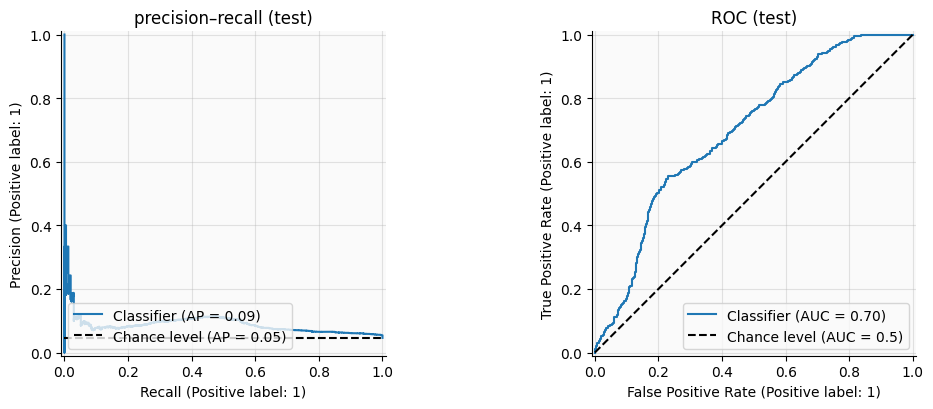

In [5]:
if y_t.sum() == 0 or (1 - y_t).sum() == 0:
    print("skip plots: need both classes on test.")
else:
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
    try:
        PrecisionRecallDisplay.from_predictions(
            y_t, s_t, ax=ax[0], plot_chance_level=True
        )
    except TypeError:
        PrecisionRecallDisplay.from_predictions(y_t, s_t, ax=ax[0])
    ax[0].set_title("precision–recall (test)")
    try:
        RocCurveDisplay.from_predictions(y_t, s_t, ax=ax[1], plot_chance_level=True)
    except TypeError:
        RocCurveDisplay.from_predictions(y_t, s_t, ax=ax[1])
    ax[1].set_title("ROC (test)")
    plt.tight_layout()
    plt.show()

### 5b] baseline: PCA reconstruction error

**idea:** fit PCA on the training rows (same `fit_row_mask` as IsolationForest), then measure per-node reconstruction error. Nodes that cannot be well-represented by the principal components are anomalous.

**score direction:** higher reconstruction error → more suspicious → calibrate via validation AUROC just like the Isolation Forest.

In [6]:
from sklearn.decomposition import PCA

N_COMPONENTS = 30

pca = PCA(n_components=N_COMPONENTS, random_state=42)
pca.fit(Xs[fit_row_mask])

Xs_pca = pca.transform(Xs)
Xs_reconstructed = pca.inverse_transform(Xs_pca)
pca_anomaly_score = np.mean((Xs - Xs_reconstructed) ** 2, axis=1)

pca_val_auroc_raw = roc_auc_score(y_illicit[m_val], pca_anomaly_score[m_val])
if pca_val_auroc_raw < 0.5:
    pca_anomaly_score = -pca_anomaly_score
    print(f"[calibration] PCA val AUROC was {pca_val_auroc_raw:.4f} → flipped scores (now {1 - pca_val_auroc_raw:.4f})")
else:
    print(f"[calibration] PCA val AUROC = {pca_val_auroc_raw:.4f} → no flip needed")

print(f"PCA components: {N_COMPONENTS}, explained variance: {pca.explained_variance_ratio_.sum():.4f}")

y_pv, s_pv = y_illicit[m_val], pca_anomaly_score[m_val]
y_pt, s_pt = y_illicit[m_test], pca_anomaly_score[m_test]

print("--- PCA reconstruction error ---")
print(
    "val :",
    f"AUROC={roc_auc_score(y_pv, s_pv):.4f}",
    f" AUPRC={average_precision_score(y_pv, s_pv):.4f}",
    f" n={len(y_pv)} illicit={int(y_pv.sum())}",
)
print(
    "test:",
    f"AUROC={roc_auc_score(y_pt, s_pt):.4f}",
    f" AUPRC={average_precision_score(y_pt, s_pt):.4f}",
    f" n={len(y_pt)} illicit={int(y_pt.sum())}",
)

[calibration] PCA val AUROC was 0.1950 → flipped scores (now 0.8050)
PCA components: 30, explained variance: 0.7603
--- PCA reconstruction error ---
val : AUROC=0.8050  AUPRC=0.4446  n=7829 illicit=675
test: AUROC=0.7547  AUPRC=0.1739  n=8841 illicit=408


### 5c] baseline: Local Outlier Factor (LOF)

**idea:** LOF measures the local density deviation of a data point with respect to its neighbours. Points in sparser regions get higher LOF scores (more anomalous).

**novelty=True:** `sklearn.neighbors.LocalOutlierFactor` with `novelty=True` fits on the clean training data and then scores new data, matching our "fit on normals, score everything" workflow.

In [7]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination="auto", novelty=True, n_jobs=-1)
lof.fit(Xs[fit_row_mask])

lof_raw = lof.score_samples(Xs)
lof_anomaly_score = -lof_raw

lof_val_auroc_raw = roc_auc_score(y_illicit[m_val], lof_anomaly_score[m_val])
if lof_val_auroc_raw < 0.5:
    lof_anomaly_score = -lof_anomaly_score
    print(f"[calibration] LOF val AUROC was {lof_val_auroc_raw:.4f} → flipped scores (now {1 - lof_val_auroc_raw:.4f})")
else:
    print(f"[calibration] LOF val AUROC = {lof_val_auroc_raw:.4f} → no flip needed")

y_lv, s_lv = y_illicit[m_val], lof_anomaly_score[m_val]
y_lt, s_lt = y_illicit[m_test], lof_anomaly_score[m_test]

print("--- local outlier factor ---")
print(
    "val :",
    f"AUROC={roc_auc_score(y_lv, s_lv):.4f}",
    f" AUPRC={average_precision_score(y_lv, s_lv):.4f}",
    f" n={len(y_lv)} illicit={int(y_lv.sum())}",
)
print(
    "test:",
    f"AUROC={roc_auc_score(y_lt, s_lt):.4f}",
    f" AUPRC={average_precision_score(y_lt, s_lt):.4f}",
    f" n={len(y_lt)} illicit={int(y_lt.sum())}",
)

[calibration] LOF val AUROC was 0.4804 → flipped scores (now 0.5196)
--- local outlier factor ---
val : AUROC=0.5196  AUPRC=0.0856  n=7829 illicit=675
test: AUROC=0.3812  AUPRC=0.0371  n=8841 illicit=408


### 6] optional: top-k highest scores on labeled test

sort by `anomaly_score` descending; inspect whether top rows are illicit (quick sanity check for reports).

In [8]:
tx = B["txId"]
topk = (
    pd.DataFrame(
        {
            "txId": tx[m_test],
            "score": anomaly_score[m_test],
            "y_illicit": y_illicit[m_test],
            "class": class_str[m_test],
            "time_step": time_step[m_test],
        }
    )
    .sort_values("score", ascending=False)
    .head(15)
)
print("top 15 suspicious (test, labeled):")
display(topk)

top 15 suspicious (test, labeled):


,txId,score,y_illicit,class,time_step
6206,125610459,-0.343729,0,2,45
7560,174257021,-0.344364,0,2,45
1715,71989395,-0.344546,1,1,42
7186,158269776,-0.344599,0,2,49
2177,73003879,-0.344872,1,1,42
5017,105784417,-0.344942,0,2,44
7638,181982228,-0.345253,0,2,45
7603,181327301,-0.345528,0,2,45
5610,106315211,-0.345555,0,2,44
7184,158269480,-0.345602,0,2,49


### 7] graph UML: setup (PyTorch Geometric)

**idea:** GCN encoder uses `edge_index`; MLP decoder reconstructs node features. **unsupervised loss** = mean squared reconstruction error on **train** nodes in `loss_node_mask` (same as **policy P1** mask when enabled).

**anomaly score:** per-node reconstruction **MSE** — higher ⇒ worse fit ⇒ more suspicious.

**training:** **train-induced** edges only (both endpoints in `train_mask`). **inference:** forward on **full** `edge_index` (transductive — disclose in your report).

**install:** `pip install torch torch-geometric` (see `requirements-elliptic-uml.txt`).

requires **§3** so `Xs` and `fit_row_mask` exist.

In [9]:
import importlib.util

if importlib.util.find_spec("torch") is None or importlib.util.find_spec("torch_geometric") is None:
    raise ImportError(
        "install PyTorch and PyTorch Geometric first, e.g.:\n"
        "  pip install torch\n"
        "  pip install torch-geometric\n"
        "see https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html"
    )

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

try:
    Xs
    fit_row_mask
except NameError as e:
    raise RuntimeError("run §1–3 first so Xs and fit_row_mask exist.") from e

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

x = torch.tensor(Xs, dtype=torch.float32, device=device)
edge_index_full = torch.tensor(edge_index, dtype=torch.long, device=device)

# vectorized train-induced mask: both endpoints inside train split
tr = train_mask
u, v = edge_index[0], edge_index[1]
keep = tr[u] & tr[v]
edge_index_train = torch.tensor(edge_index[:, keep], dtype=torch.long, device=device)

loss_node_mask = torch.tensor(fit_row_mask, dtype=torch.bool, device=device)
in_dim = x.size(1)

print("full edges:", edge_index.shape[1], "| train-induced edges:", int(edge_index_train.shape[1]))

device: cpu
full edges: 234355 | train-induced edges: 156843


### 8] graph autoencoder: layers + forward function (no custom class)

modules are plain `GCNConv` / `Linear` layers with **dropout** (p=0.3) on encoder and decoder hidden activations to reduce overfitting. **`graph_ae_forward`** is the only **`def`** in this notebook (graph forward pass); baseline models, masks, metrics, and plots are straight-line code above.

**improvements over baseline:** dropout regularization, reduced learning rate (0.005), increased max epochs (200), and **validation-based early stopping** (patience=20 on val reconstruction MSE).

In [10]:
HID, LATENT = 128, 64
DROPOUT = 0.3

g_conv1 = GCNConv(in_dim, HID).to(device)
g_conv2 = GCNConv(HID, LATENT).to(device)
g_dec1 = nn.Linear(LATENT, HID).to(device)
g_dec2 = nn.Linear(HID, in_dim).to(device)
g_drop = nn.Dropout(p=DROPOUT)


def graph_ae_forward(x_in, eidx, c1, c2, d1, d2, drop, training=True):
    h = drop(F.relu(c1(x_in, eidx))) if training else F.relu(c1(x_in, eidx))
    z = F.relu(c2(h, eidx))
    h2 = drop(F.relu(d1(z))) if training else F.relu(d1(z))
    recon = d2(h2)
    return recon, z


val_node_mask = torch.tensor(val_mask & labeled, dtype=torch.bool, device=device)
val_y = torch.tensor(y_illicit[val_mask & labeled], dtype=torch.float32)

params = list(g_conv1.parameters()) + list(g_conv2.parameters()) + list(g_dec1.parameters()) + list(g_dec2.parameters())
opt = torch.optim.Adam(params, lr=0.005, weight_decay=1e-5)

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

EPOCHS = 200
PATIENCE = 20
best_val_loss = float("inf")
patience_counter = 0
best_state = None

for ep in range(1, EPOCHS + 1):
    g_conv1.train(); g_conv2.train(); g_dec1.train(); g_dec2.train()
    opt.zero_grad()
    recon, _ = graph_ae_forward(x, edge_index_train, g_conv1, g_conv2, g_dec1, g_dec2, g_drop, training=True)
    err = (recon - x) ** 2
    loss = err[loss_node_mask].mean()
    loss.backward()
    opt.step()

    g_conv1.eval(); g_conv2.eval(); g_dec1.eval(); g_dec2.eval()
    with torch.no_grad():
        recon_v, _ = graph_ae_forward(x, edge_index_full, g_conv1, g_conv2, g_dec1, g_dec2, g_drop, training=False)
        val_loss = ((recon_v - x) ** 2)[val_node_mask].mean().item()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.clone() for k, v in
                      {**dict(zip(["c1_" + n for n in [p[0] for p in g_conv1.named_parameters()]], g_conv1.parameters())),
                       **dict(zip(["c2_" + n for n in [p[0] for p in g_conv2.named_parameters()]], g_conv2.parameters())),
                       **dict(zip(["d1_" + n for n in [p[0] for p in g_dec1.named_parameters()]], g_dec1.parameters())),
                       **dict(zip(["d2_" + n for n in [p[0] for p in g_dec2.named_parameters()]], g_dec2.parameters()))}.items()}
    else:
        patience_counter += 1

    if ep % 20 == 0 or ep == 1:
        print(f"epoch {ep:3d}  train_mse={loss.item():.6f}  val_mse={val_loss:.6f}  patience={patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"early stop at epoch {ep} (best val_mse={best_val_loss:.6f})")
        break

if best_state is not None:
    g_conv1.load_state_dict({k.replace("c1_", ""): v for k, v in best_state.items() if k.startswith("c1_")})
    g_conv2.load_state_dict({k.replace("c2_", ""): v for k, v in best_state.items() if k.startswith("c2_")})
    g_dec1.load_state_dict({k.replace("d1_", ""): v for k, v in best_state.items() if k.startswith("d1_")})
    g_dec2.load_state_dict({k.replace("d2_", ""): v for k, v in best_state.items() if k.startswith("d2_")})

print("training done (train-induced edges; loss on train nodes only; best model restored).")

epoch   1  train_mse=1.069020  val_mse=9.925260  patience=0/20
epoch  20  train_mse=0.777851  val_mse=7.362161  patience=0/20
epoch  40  train_mse=0.695879  val_mse=5.539528  patience=0/20
epoch  60  train_mse=0.650189  val_mse=5.131857  patience=0/20
epoch  80  train_mse=0.621847  val_mse=4.942277  patience=5/20
early stop at epoch 95 (best val_mse=4.940610)
training done (train-induced edges; loss on train nodes only; best model restored).


### 9] graph AE scores and metrics on val / test

In [11]:
g_conv1.eval()
g_conv2.eval()
g_dec1.eval()
g_dec2.eval()

with torch.no_grad():
    recon_full, _ = graph_ae_forward(x, edge_index_full, g_conv1, g_conv2, g_dec1, g_dec2, g_drop, training=False)
    per_node_mse = ((recon_full - x) ** 2).mean(dim=1).cpu().numpy()

graph_anomaly_score = per_node_mse

gae_val_auroc_raw = roc_auc_score(y_illicit[m_val], graph_anomaly_score[m_val])
if gae_val_auroc_raw < 0.5:
    graph_anomaly_score = -graph_anomaly_score
    print(f"[calibration] graph AE val AUROC was {gae_val_auroc_raw:.4f} → flipped scores (now {1 - gae_val_auroc_raw:.4f})")
else:
    print(f"[calibration] graph AE val AUROC = {gae_val_auroc_raw:.4f} → no flip needed")

print("--- graph AE (GCN + MLP) ---")

y_gv, s_gv = y_illicit[m_val], graph_anomaly_score[m_val]
y_gt, s_gt = y_illicit[m_test], graph_anomaly_score[m_test]

if y_gv.sum() == 0 or (1 - y_gv).sum() == 0:
    print("val (graph AE): skip (need both classes)")
else:
    print(
        "val (graph AE):",
        f"AUROC={roc_auc_score(y_gv, s_gv):.4f}",
        f" AUPRC={average_precision_score(y_gv, s_gv):.4f}",
    )
if y_gt.sum() == 0 or (1 - y_gt).sum() == 0:
    print("test (graph AE): skip (need both classes)")
else:
    print(
        "test (graph AE):",
        f"AUROC={roc_auc_score(y_gt, s_gt):.4f}",
        f" AUPRC={average_precision_score(y_gt, s_gt):.4f}",
    )

[calibration] graph AE val AUROC was 0.2141 → flipped scores (now 0.7859)
--- graph AE (GCN + MLP) ---
val (graph AE): AUROC=0.7859  AUPRC=0.4114
test (graph AE): AUROC=0.7337  AUPRC=0.2114


### 9b] ensemble: average-rank fusion

**idea:** convert each method's anomaly scores to percentile ranks (0–1), then average across all four methods. This gives a model-agnostic fusion that is robust to different score scales.

**methods fused:** Isolation Forest, PCA, LOF, Graph AE (GCN).

In [12]:
from scipy.stats import rankdata

def to_percentile_rank(scores):
    return rankdata(scores, method="average") / len(scores)

rank_if = to_percentile_rank(anomaly_score)
rank_pca = to_percentile_rank(pca_anomaly_score)
rank_lof = to_percentile_rank(lof_anomaly_score)
rank_gae = to_percentile_rank(graph_anomaly_score)

ensemble_score = (rank_if + rank_pca + rank_lof + rank_gae) / 4.0

ens_val_auroc_raw = roc_auc_score(y_illicit[m_val], ensemble_score[m_val])
if ens_val_auroc_raw < 0.5:
    ensemble_score = 1.0 - ensemble_score
    print(f"[calibration] ensemble val AUROC was {ens_val_auroc_raw:.4f} → flipped ranks (now {1 - ens_val_auroc_raw:.4f})")
else:
    print(f"[calibration] ensemble val AUROC = {ens_val_auroc_raw:.4f} → no flip needed")

y_ev, s_ev = y_illicit[m_val], ensemble_score[m_val]
y_et, s_et = y_illicit[m_test], ensemble_score[m_test]

print("--- ensemble (average rank) ---")
print(
    "val :",
    f"AUROC={roc_auc_score(y_ev, s_ev):.4f}",
    f" AUPRC={average_precision_score(y_ev, s_ev):.4f}",
    f" n={len(y_ev)} illicit={int(y_ev.sum())}",
)
print(
    "test:",
    f"AUROC={roc_auc_score(y_et, s_et):.4f}",
    f" AUPRC={average_precision_score(y_et, s_et):.4f}",
    f" n={len(y_et)} illicit={int(y_et.sum())}",
)

[calibration] ensemble val AUROC = 0.8243 → no flip needed
--- ensemble (average rank) ---
val : AUROC=0.8243  AUPRC=0.3705  n=7829 illicit=675
test: AUROC=0.7241  AUPRC=0.1209  n=8841 illicit=408


### 10] summary table and bar chart (**AUROC**)

compare all five methods: **Isolation Forest**, **PCA**, **LOF**, **Graph AE (GCN)** and **Ensemble (avg rank)** on the same labeled splits.

metric summary:


,split,model,AUROC,AUPRC
0,val,isolation forest,0.862689,0.390427
1,val,PCA recon error,0.804993,0.444606
2,val,LOF,0.519646,0.085625
3,val,graph AE (GCN),0.785930,0.411360
4,val,ensemble (avg rank),0.824315,0.370509
5,test,isolation forest,0.697537,0.088897
6,test,PCA recon error,0.754671,0.173890
7,test,LOF,0.381196,0.037077
8,test,graph AE (GCN),0.733662,0.211354
9,test,ensemble (avg rank),0.724139,0.120878


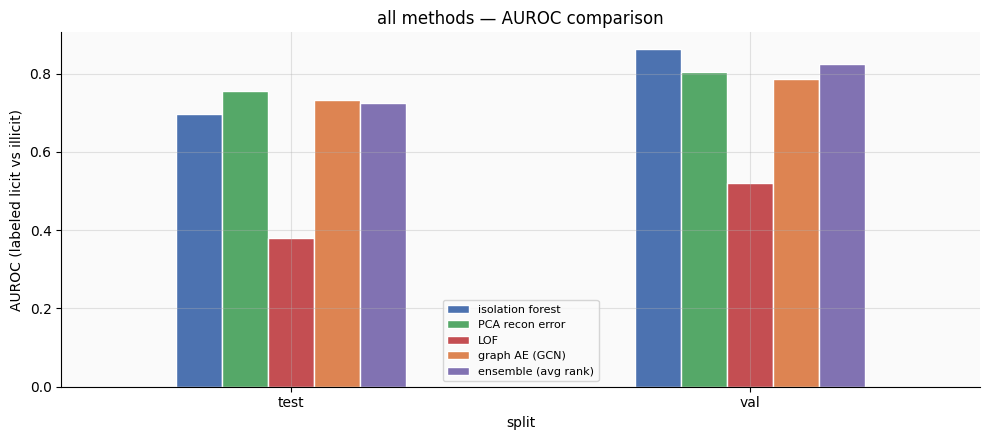

In [13]:
model_scores = [
    ("isolation forest", anomaly_score),
    ("PCA recon error", pca_anomaly_score),
    ("LOF", lof_anomaly_score),
    ("graph AE (GCN)", graph_anomaly_score),
    ("ensemble (avg rank)", ensemble_score),
]

rows = []
for split_name, mask in [("val", m_val), ("test", m_test)]:
    y = y_illicit[mask]
    if y.sum() == 0 or (1 - y).sum() == 0:
        continue
    for model_name, scores in model_scores:
        rows.append(
            {
                "split": split_name,
                "model": model_name,
                "AUROC": roc_auc_score(y, scores[mask]),
                "AUPRC": average_precision_score(y, scores[mask]),
            }
        )

summary = pd.DataFrame(rows)
print("metric summary:")
display(summary)

colors = ["#4c72b0", "#55a868", "#c44e52", "#dd8452", "#8172b2"]
fig, ax = plt.subplots(figsize=(10, 4.5))
pivot = summary.pivot(index="split", columns="model", values="AUROC")
pivot[[m for m, _ in model_scores]].plot(kind="bar", ax=ax, rot=0, color=colors, edgecolor="white")
ax.set_ylabel("AUROC (labeled licit vs illicit)")
ax.set_title("all methods — AUROC comparison")
ax.legend(title=None, frameon=True, fontsize=8)
plt.tight_layout()
plt.show()

### 10b] export scores for report notebook (03)

Run this cell after the metric summary so **`artifacts/eval_bundle.pkl`** exists. Notebook **03** loads this file and does not refit models.

In [14]:
summary_report = summary.copy()
summary_report["split"] = summary_report["split"].replace({"val": "validation"})
mask_map = {"validation": m_val, "test": m_test}
ns, ins = [], []
for _, r in summary_report.iterrows():
    m = mask_map[r["split"]]
    y = y_illicit[m]
    ns.append(len(y))
    ins.append(int(y.sum()))
summary_report["n"] = ns
summary_report["illicit_n"] = ins

eval_bundle = {
    "anomaly_score": np.asarray(anomaly_score, dtype=np.float64),
    "pca_anomaly_score": np.asarray(pca_anomaly_score, dtype=np.float64),
    "lof_anomaly_score": np.asarray(lof_anomaly_score, dtype=np.float64),
    "graph_anomaly_score": np.asarray(graph_anomaly_score, dtype=np.float64),
    "ensemble_score": np.asarray(ensemble_score, dtype=np.float64),
    "results_df": summary_report,
    "exclude_illicit_from_fit": EXCLUDE_ILLICIT_FROM_FIT,
}
out = ARTIFACTS / "eval_bundle.pkl"
with open(out, "wb") as f:
    pickle.dump(eval_bundle, f)
print("wrote", out, "— run notebook 03 next")

wrote f:\msc ds\semester 2\UML\uml project\elliptic_bitcoin_project\artifacts\eval_bundle.pkl — run notebook 03 next


***